In [75]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import os
import json
import sys
import datetime
from datetime import date, datetime, timedelta
from matplotlib.dates import MO, TU, WeekdayLocator, MonthLocator, YearLocator
from datetime import datetime, UTC, date, timezone
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Rectangle
from matplotlib.ticker import PercentFormatter, StrMethodFormatter
import numpy as np

plots_filepath = 'plots/june-25/'

# Append utils to path for logo import
sys.path.append("utils")
from logo import add_logo


# Make the data on each chart today's date
def format_date_with_suffix(date_obj):
    day = date_obj.day
    # Determine the ordinal suffix
    if 10 <= day % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(day % 10, 'th')
    return date_obj.strftime(f"%B {day}{suffix}, %Y")

today = datetime.today()
date = format_date_with_suffix(today)

# Color utils
color_palette = {'Hyperliquid':'#09b882','Bold Blue':'#1f1f60', 'Sky Blue':'#6f85ee', 'Solana Purple':'#9945FF','Engage Orange':'#eda024', 'Dark Slate':'#262935', 'Mauve':'#7c1158', 'Yellow':'#ebdc78', 'Green':'#00b7c7', 'Red':'#b30000','Mid Grey':'#54504c','Other Grey':'#a4a2a8', 'Pure Grey': '#808080','Lighter Grey': '#A9A9A9','Lightest Grey': '#D3D3D3','blue 1':'#03045e', 'blue 2':'#0077b6', 'blue 3':'#00b4d8', 'blue 4':'#90e0ef', 'blue 5':'#caf0f8'}
platform_colors = {
        'Felix': color_palette['Sky Blue'],  
        'Hyperliquid': color_palette['Hyperliquid'],  
        'Jupiter': color_palette['Bold Blue'],      
        'dYdX v4': color_palette['Sky Blue'],      
        'ApeX': color_palette['Engage Orange'],         
        'Holdstation': color_palette['Yellow'],  
        'Vertex Protocol': color_palette['Green'], 
        'GMX': color_palette['Red'],          
        'dYdX v3': color_palette['Dark Slate'],      
        'Drift Protocol': color_palette['Mauve'],
        'RabbitX': color_palette['Mid Grey'],           
        'dYdX': color_palette['Dark Slate'],
        'Gains Network': color_palette['Mauve'],
        'KTX Finance': color_palette['Yellow'],
        'RabbitX': color_palette['Pure Grey'],
        'Aevo': color_palette['Lighter Grey'],
        'Other': color_palette['Other Grey'],
        'Hyperliquid Perps': color_palette['Hyperliquid'],
        'Jupiter Perpetual Exchange': color_palette['Bold Blue'],
        'Vertex Perps': color_palette['Green'],
        'Apex Omni': color_palette['Engage Orange'],
        'MYX Finance': color_palette['Yellow'],
        'edgeX': color_palette['Red'],
        'Ostium': color_palette['Mauve'],
        'RabitX': color_palette['Yellow'],
        'Aark Digital': color_palette['Dark Slate'],
        'dYdX (V3+V4)': color_palette['Sky Blue']
    }

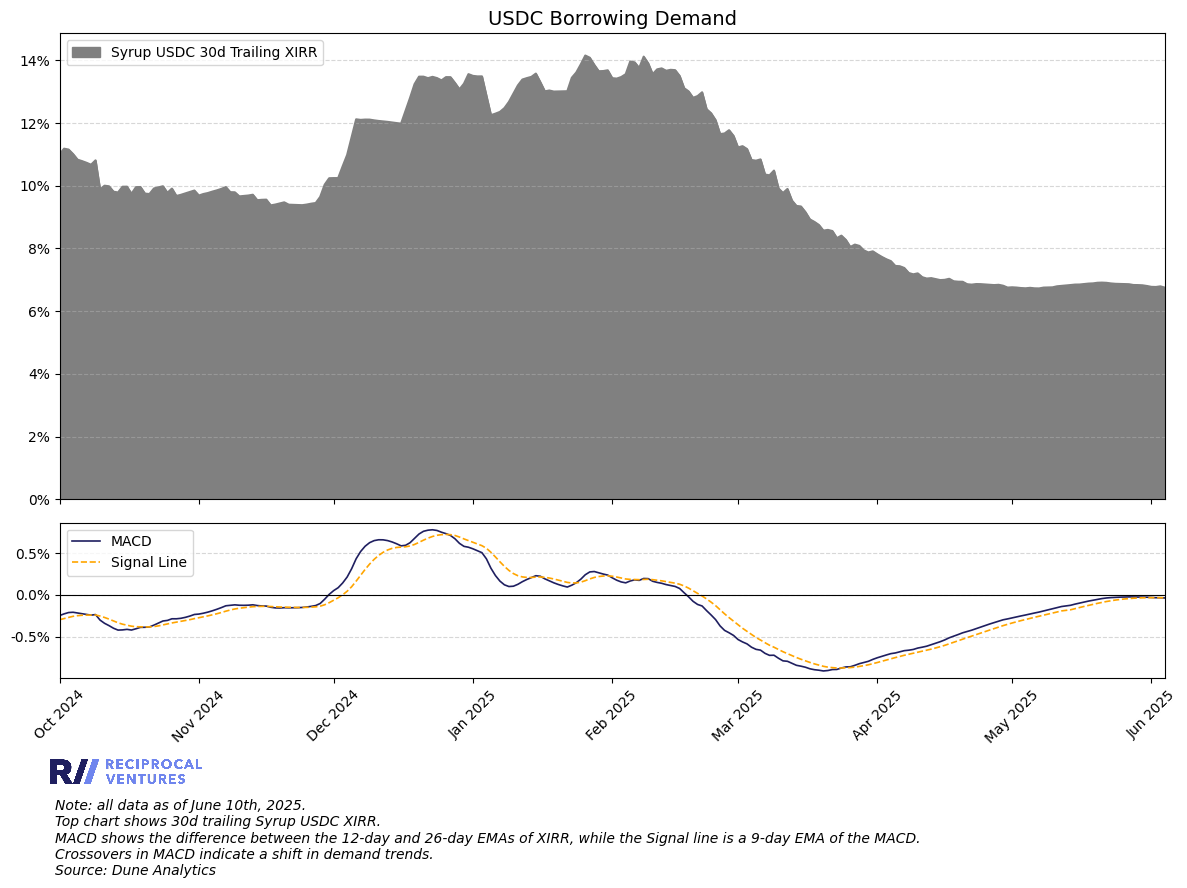

In [76]:
# Load the JSON file
with open("raw-data/dune-raw-data/dune_maple-xirr.json", "r") as f:
    raw_data = json.load(f)

# Extract relevant rows only for "Syrup USDC"
entries = raw_data["result"]["rows"]
syrup_usdc_rows = [e for e in entries if e["pool_name"] == "Syrup USDC"]

# Convert to DataFrame
df = pd.DataFrame(syrup_usdc_rows)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df['percent_xirr'] = df['trailing_xirr'] * 100

# Compute EMA and MACD
def compute_ema(values, period):
    ema = [None] * len(values)
    multiplier = 2 / (period + 1)

    # Find first index with enough non-None values
    valid_start = next((i for i in range(len(values)) if values[i] is not None), None)
    if valid_start is None or valid_start + period > len(values):
        return ema  # not enough data

    # Initialize EMA at first valid point
    ema[valid_start + period] = sum(values[valid_start:valid_start + period]) / period

    for i in range(valid_start + period + 1, len(values)):
        if values[i] is not None and ema[i - 1] is not None:
            ema[i] = (values[i] - ema[i - 1]) * multiplier + ema[i - 1]

    return ema

# Extract values
dates = df["date"].tolist()
percent_xirrs = df['percent_xirr'].tolist()

# Calculate EMAs and MACD
ema_12 = compute_ema(percent_xirrs, 12)
ema_26 = compute_ema(percent_xirrs, 26)
macd = [e12 - e26 if e12 is not None and e26 is not None else None for e12, e26 in zip(ema_12, ema_26)]

# Clean None values from MACD before computing signal line
macd_cleaned = [v if v is not None else 0 for v in macd]
signal = compute_ema(macd_cleaned, 9)

# Add back to the dataframe
df['ema_12'] = ema_12
df['ema_26'] = ema_26
df['macd'] = macd_cleaned
df['signal'] = signal

# Filter to cutoff date
df = df[df["date"] >= '2024-10-01'].reset_index(drop=True)

# Create figure with two subplots (main + MACD)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Area chart for XIRR
ax1.fill_between(df['date'], df['percent_xirr'], color=color_palette['Pure Grey'], alpha=1, label="Syrup USDC 30d Trailing XIRR")
ax1.plot(df['date'], df['percent_xirr'], color=color_palette['Pure Grey'], linewidth=1.5)
ax1.set_title("USDC Borrowing Demand", fontsize=14)
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.legend(loc="upper left")
ax1.set_ylim(bottom=0)

# MACD Indicator
# MACD shows the difference between the 12-day and 26-day EMAs of XIRR, while the Signal line is a 9-day EMA of the MACD. Crossovers may indicate shifts in APY momentum.
ax2.plot(df['date'], df['macd'], label="MACD", color="#1f1f60", linewidth=1.2)
ax2.plot(df['date'], df['signal'], label="Signal Line", color="orange", linestyle="--", linewidth=1.2)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="-")
ax2.grid(axis="y", linestyle="--", alpha=0.5)
ax2.legend(loc="upper left")

# X-axis formatting
ax1.margins(x=0)
ax2.margins(x=0)
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Format y-axis on main chart as %
def percent_formatter_no_decimal(x, pos):
    return f"{x:.0f}%"
def percent_formatter(x, pos):
    return f"{x:.1f}%"
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(percent_formatter_no_decimal))
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(percent_formatter))

# Add Reciprocal logo and source note
add_logo(ax2, position=(0.06, -0.6))
plt.figtext(0.05, -0.1, f"Note: all data as of {date}.\nTop chart shows 30d trailing Syrup USDC XIRR.\nMACD shows the difference between the 12-day and 26-day EMAs of XIRR, while the Signal line is a 9-day EMA of the MACD.\nCrossovers in MACD indicate a shift in demand trends.\nSource: Dune Analytics", ha='left', fontsize=10, style='italic')

# Save and show
imgtitle = "usdc-30d-trailing-xirr-and-macd"
plt.tight_layout()
save_path = os.path.join("plots/june-25/", f"{imgtitle}.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

In [77]:
# Function to plot top protocols by fees or revenue
def top_n_protocols_by_category(metric, category, start_date, end_date, n):
    with open(f'raw-data/defillama-raw-data/{metric}_data/top-protocols-{category}.json', 'r') as f:
        protocols = json.load(f)
    
    asset_colors = ['#1f1f60',
                    '#191F98',
                    '#313EA5',
                    '#4A5DB2',
                    '#637BBF',
                    '#7C9ACC',
                    '#94B9D9',
                    '#ADD8E6',
                    '#333333',
                    '#494949',
                    '#5F5F5F',
                    '#757575',
                    '#8A8A8A',
                    '#A0A0A0',
                    '#B6B6B6',
                    '#CCCCCC'
                   ]
    
    df_master = None
    
    counter = 0
    
    start_date_dt = pd.to_datetime(start_date)
    end_date_dt = pd.to_datetime(end_date) - pd.Timedelta(days=1)
    
    for raw_id, asset in protocols.items():
        with open(f'raw-data/defillama-raw-data/{metric}_data/{raw_id}.json') as f:
            data = json.load(f)
        
        # Select only the two real keys, then rename
        raw_df = pd.DataFrame(
            data['totalDataChart'],
            columns=['date', f'{metric}']
        )
        raw_df.rename(columns={
            'date': 'timestamp',
            f'{metric}': asset
        }, inplace=True)
        raw_df['date'] = pd.to_datetime(raw_df['timestamp'], unit='s')
        raw_df = raw_df[['date', asset]]
        raw_df[asset] = raw_df[asset].rolling(window=7).mean()
    
        # Merge dataframes
        df_master = raw_df if df_master is None else df_master.merge(raw_df, on='date', how='outer')
        df_master.fillna(0, inplace=True)
    
        # Iterate coutner by 1
        counter += 1
        
    # Filter by appropriate dates
    df_master = df_master.loc[(df_master['date'] >= start_date_dt) &
    (df_master['date'] < end_date_dt)
    ]
        
    # Sort your master dataframe by date
    df_master = df_master.sort_values('date')
    
    # Grab the last row of numbers
    last_row = df_master.iloc[-1]
    
    # Sort the asset names by descending value on that last row
    asset_list = sorted(
        protocols.values(),
        key=lambda asset: last_row[asset],
        reverse=True
    )

    # Filter asset by desired numbe of protocols
    asset_list = asset_list[:n]

    if n < counter:
        counter = n

    
    # Prepare the values and colors in the right order
    dates   = df_master['date']
    series  = [df_master[asset] for asset in asset_list]
    colors = asset_colors[:len(asset_list)]
    
    # Plot a single stacked‐area call
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.stackplot(
        dates,
        *series,
        labels=asset_list,
        colors=colors
    )
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000000:.0f}m'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    
    ax.legend(loc='upper left', bbox_to_anchor=(0,1), ncol=2)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.08, -0.17))
    ax.margins(x=0)
    plt.figtext(0.12, -0.11, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')
    if metric == 'dailyFees':
        ax.set_title(f'Top {counter} {category} by Daily Fees')
    if metric == 'dailyRevenue':
        ax.set_title(f'Top {counter} {category} by Daily Revenue')
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/{category}-{metric}.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(df_master.tail(5))

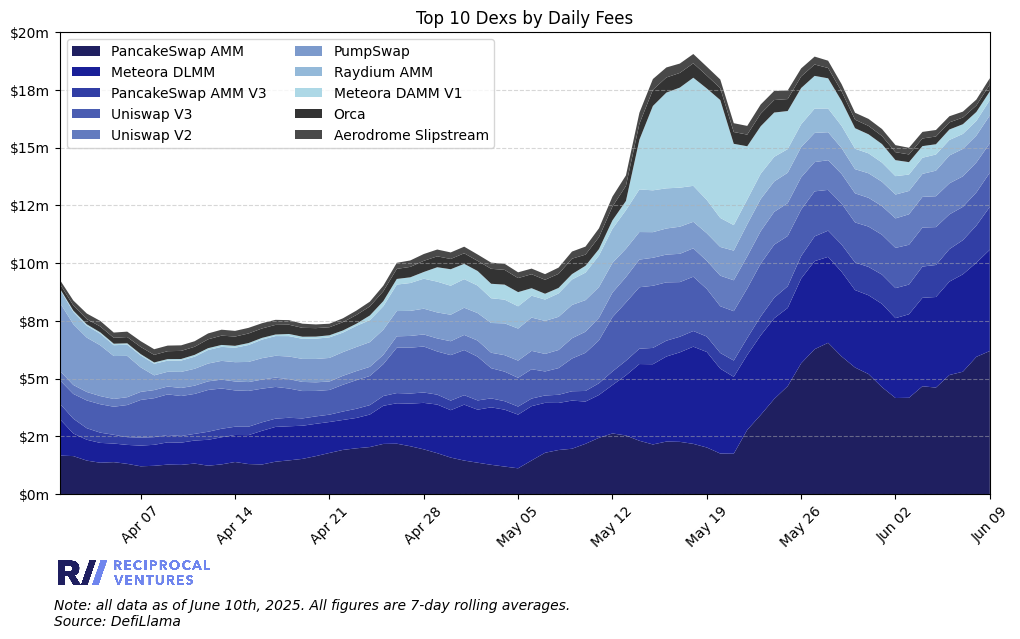

           date  PancakeSwap AMM  Meteora DLMM  Hyperliquid Spot Orderbook  \
1850 2025-06-05     4.607802e+06  3.922494e+06                2.032775e+06   
1851 2025-06-06     5.151861e+06  4.044444e+06                1.868835e+06   
1852 2025-06-07     5.295432e+06  4.217418e+06                1.819220e+06   
1853 2025-06-08     5.939125e+06  4.073752e+06                1.783056e+06   
1854 2025-06-09     6.191786e+06  4.387313e+06                0.000000e+00   

        Uniswap V3  Meteora DAMM V1    Uniswap V2  PancakeSwap AMM V3  \
1850  1.641107e+06    443934.142857  1.336522e+06        1.385710e+06   
1851  1.503796e+06    452489.714286  1.344721e+06        1.406972e+06   
1852  1.442659e+06    419046.714286  1.320835e+06        1.478735e+06   
1853  1.433487e+06    388587.857143  1.296996e+06        1.610724e+06   
1854  1.480759e+06    376311.857143  1.269957e+06        1.855286e+06   

          PumpSwap    Raydium AMM           Orca  Aerodrome Slipstream  \
1850  1.106943e+06

In [78]:
# Call the function
metric = 'dailyFees' # 'dailyFees' or 'dailyRevenue'
category = 'Dexs'
start_date = '2025-04-01'
end_date = today
n = 10 # number of protocols to show, max is number pulled down in the raw data

top_n_protocols_by_category(metric, category, start_date, end_date, n)

In [79]:
# Function compare fees or revenue for a subsect of assets
def compare_assets(metric, category, breakout_assets, start_date, end_date):
    with open(f'raw-data/defillama-raw-data/{metric}_data/top-protocols-{category}.json', 'r') as f:
        protocols = json.load(f)
    
    asset_colors = ['#1f1f60',
                    '#4A5DB2',
                    '#494949',
                    '#A0A0A0'
                   ]
    
    df_master = None

    compare_dict = {}

    start_date_dt = pd.to_datetime(start_date)
    end_date_dt = pd.to_datetime(end_date) - pd.Timedelta(days=1)
    
    for raw_id, asset in protocols.items():
        if asset in breakout_assets:
            compare_dict[raw_id] = asset
            with open(f'raw-data/defillama-raw-data/{metric}_data/{raw_id}.json') as f:
                data = json.load(f)
            
            # Select only the two real keys, then rename
            raw_df = pd.DataFrame(
                data['totalDataChart'],
                columns=['date', f'{metric}']
            )
            raw_df.rename(columns={
                'date': 'timestamp',
                f'{metric}': asset
            }, inplace=True)
            raw_df['date'] = pd.to_datetime(raw_df['timestamp'], unit='s')
            raw_df = raw_df[['date', asset]]
        
            # Merge dataframes
            df_master = raw_df if df_master is None else df_master.merge(raw_df, on='date', how='outer')
            df_master.fillna(0, inplace=True)

    # Filter by appropriate dates
    df_master = df_master.loc[(df_master['date'] >= start_date_dt) &
    (df_master['date'] < end_date_dt)
    ]
    
    # Sort your master dataframe by date
    df_master = df_master.sort_values('date')
    print(df_master.tail(5))
    
    # Grab the last row of numbers
    last_row = df_master.iloc[-1]
    
    # Sort the asset names by descending value on that last row
    asset_list = sorted(
        compare_dict.values(),
        key=lambda asset: last_row[asset],
        reverse=True
    )
    
    # Prepare the values and colors in the right order
    dates   = df_master['date']
    series  = [df_master[asset] for asset in asset_list]
    colors = asset_colors[:len(asset_list)]
    
    # Plot a single stacked‐area call
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.stackplot(
        dates,
        *series,
        labels=asset_list,
        colors=colors
    )
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000000:.0f}m'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    
    ax.legend(loc='upper left', bbox_to_anchor=(0,1), ncol=3)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.08, -0.17))
    ax.margins(x=0)
    plt.figtext(0.12, -0.11, f"Note: all data as of {date}. \nSource: DefiLlama", ha='left', fontsize=10, style='italic')
    if metric == 'dailyFees':
        ax.set_title(f'{category}: Daily Fees Comparison')
    if metric == 'dailyRevenue':
        ax.set_title(f'{category}: Daily Revenue Comparison')
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/breakout-{category}-{metric}-stacked.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(df_master.tail(5))

          date  Hyperliquid Spot Orderbook   PumpSwap  Raydium AMM      Orca
962 2025-06-05                   3093273.0  1827299.0     734083.0  424618.0
963 2025-06-06                   1869461.0  1660320.0     614103.0  261754.0
964 2025-06-07                    918833.0   929848.0     452261.0  154783.0
965 2025-06-08                    820745.0   828612.0     432325.0  176619.0
966 2025-06-09                         0.0  1279257.0     777824.0  425916.0


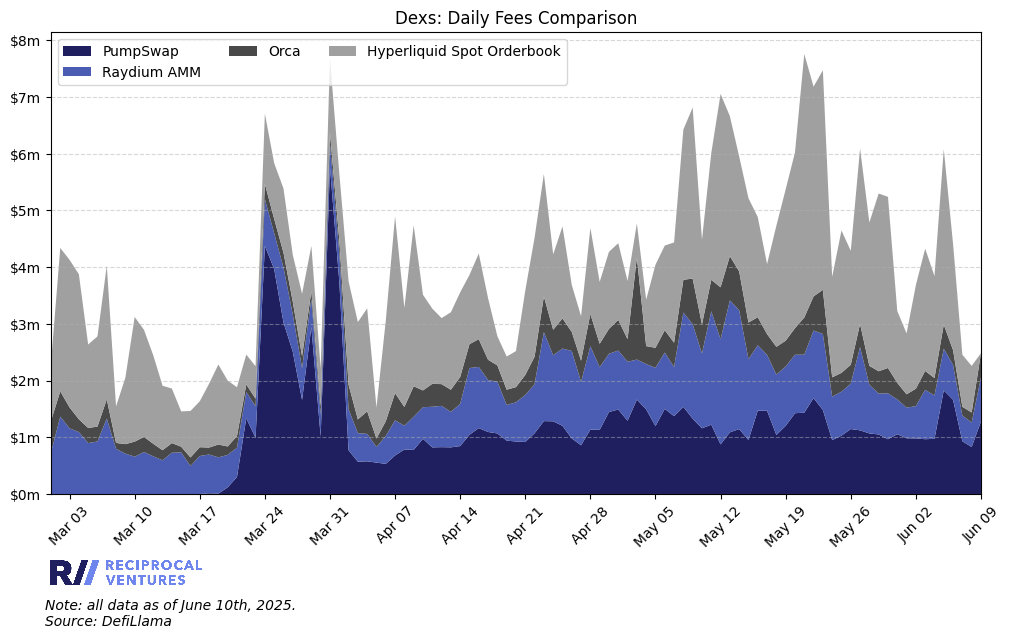

          date  Hyperliquid Spot Orderbook   PumpSwap  Raydium AMM      Orca
962 2025-06-05                   3093273.0  1827299.0     734083.0  424618.0
963 2025-06-06                   1869461.0  1660320.0     614103.0  261754.0
964 2025-06-07                    918833.0   929848.0     452261.0  154783.0
965 2025-06-08                    820745.0   828612.0     432325.0  176619.0
966 2025-06-09                         0.0  1279257.0     777824.0  425916.0


In [80]:
# Call the function
category = 'Dexs'
start_date = '2025-03-01'
end_date = today
breakout_assets = ['Hyperliquid Spot Orderbook', 'PumpSwap', 'Raydium AMM', 'Orca']

compare_assets(metric, category, breakout_assets, start_date, end_date)

In [81]:
# Function compare fees or revenue for a subsect of assets
def compare_assets(metric, category, breakout_assets, start_date, end_date):
    with open(f'raw-data/defillama-raw-data/{metric}_data/top-protocols-{category}.json', 'r') as f:
        protocols = json.load(f)
    
    asset_colors = ['#1f1f60',
                    '#4A5DB2',
                    '#494949',
                    '#A0A0A0'
                   ]
    
    df_master = None

    compare_dict = {}

    start_date_dt = pd.to_datetime(start_date)
    end_date_dt = pd.to_datetime(end_date) - pd.Timedelta(days=1)
    
    for raw_id, asset in protocols.items():
        if asset in breakout_assets:
            compare_dict[raw_id] = asset
            with open(f'raw-data/defillama-raw-data/{metric}_data/{raw_id}.json') as f:
                data = json.load(f)
            
            # Select only the two real keys, then rename
            raw_df = pd.DataFrame(
                data['totalDataChart'],
                columns=['date', f'{metric}']
            )
            raw_df.rename(columns={
                'date': 'timestamp',
                f'{metric}': asset
            }, inplace=True)
            raw_df['date'] = pd.to_datetime(raw_df['timestamp'], unit='s')
            raw_df = raw_df[['date', asset]]
            raw_df[asset] = raw_df[asset].rolling(window=7).mean()
        
            # Merge dataframes
            df_master = raw_df if df_master is None else df_master.merge(raw_df, on='date', how='outer')
            df_master.fillna(0, inplace=True)

    # Filter by appropriate dates
    df_master = df_master.loc[(df_master['date'] >= start_date_dt) &
    (df_master['date'] < end_date_dt)
    ]
    
    # Sort your master dataframe by date
    df_master = df_master.sort_values('date')
    print(df_master.tail(5))
    
    # Grab the last row of numbers
    last_row = df_master.iloc[-1]
    
    # Sort the asset names by descending value on that last row
    asset_list = sorted(
        compare_dict.values(),
        key=lambda asset: last_row[asset],
        reverse=True
    )
    
    # Plot a single stacked‐area call
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, asset in enumerate(asset_list):
        ax.plot(
            df_master['date'],
            df_master[asset],
            color = asset_colors[i],
            linewidth = 2,
            label=asset
        )
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000000:.0f}m'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    
    ax.legend(loc='upper left', bbox_to_anchor=(0,1), ncol=2)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.08, -0.17))
    ax.margins(x=0)
    plt.figtext(0.12, -0.11, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')
    if metric == 'dailyFees':
        ax.set_title(f'{category}: Daily Fees Comparison')
    if metric == 'dailyRevenue':
        ax.set_title(f'{category}: Daily Revenue Comparison')
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/breakout-{category}-{metric}-line.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(df_master.tail(5))

          date  Hyperliquid Spot Orderbook      PumpSwap    Raydium AMM  \
962 2025-06-05                2.032775e+06  1.106943e+06  699881.285714   
963 2025-06-06                1.868835e+06  1.206193e+06  672063.428571   
964 2025-06-07                1.819220e+06  1.188413e+06  649073.714286   
965 2025-06-08                1.783056e+06  1.166402e+06  633790.142857   
966 2025-06-09                0.000000e+00  1.209090e+06  663684.428571   

              Orca  
962  335515.000000  
963  308949.857143  
964  289320.000000  
965  280902.000000  
966  297774.714286  


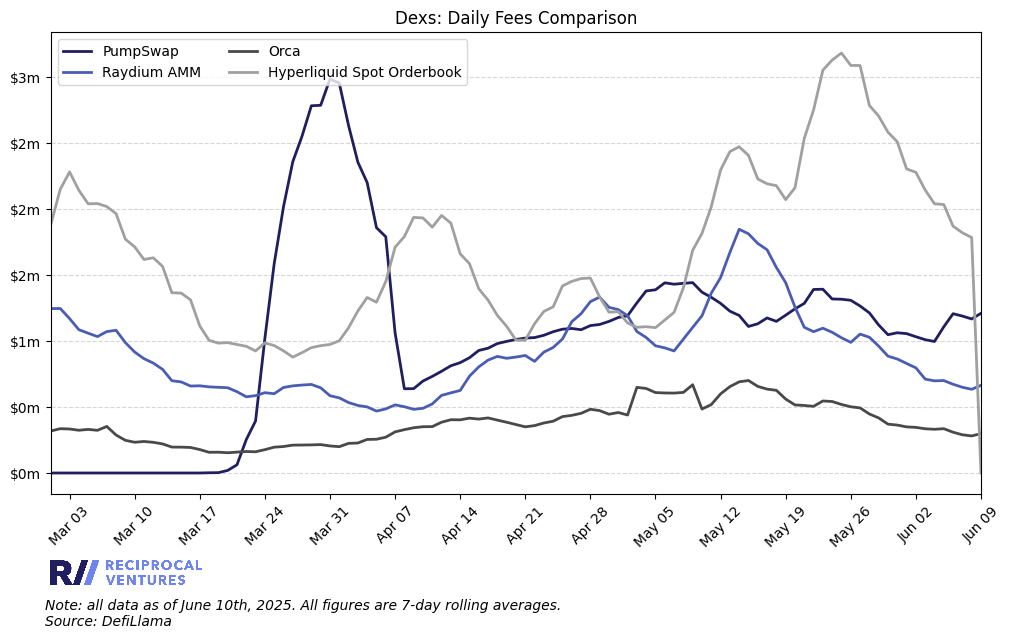

          date  Hyperliquid Spot Orderbook      PumpSwap    Raydium AMM  \
962 2025-06-05                2.032775e+06  1.106943e+06  699881.285714   
963 2025-06-06                1.868835e+06  1.206193e+06  672063.428571   
964 2025-06-07                1.819220e+06  1.188413e+06  649073.714286   
965 2025-06-08                1.783056e+06  1.166402e+06  633790.142857   
966 2025-06-09                0.000000e+00  1.209090e+06  663684.428571   

              Orca  
962  335515.000000  
963  308949.857143  
964  289320.000000  
965  280902.000000  
966  297774.714286  


In [82]:
# Call the function
category = 'Dexs'
start_date = '2025-03-01'
end_date = today
breakout_assets = ['Hyperliquid Spot Orderbook', 'PumpSwap', 'Raydium AMM', 'Orca']

compare_assets(metric, category, breakout_assets, start_date, end_date)

In [83]:
# Function for plotting revenue or fees / mcap or fdv charts for a set of assets

def revenue_vs_fdv_asset(start_date, assets, breakout_asset, bottom_metric, top_metric, category_title):
    df_master = None
    # Load revenue and FDV data
    for asset_slug, asset_name in assets.items():
        rev_path = f"raw-data/defillama-raw-data/defillama_{asset_slug}_{bottom_metric}.json"
        with open(rev_path) as rev_f:
            rev_data = json.load(rev_f)
    
        rev_df = pd.DataFrame(rev_data["totalDataChart"], columns=["timestamp", f"{asset_slug}-{bottom_metric}"])
        rev_df["date"] = pd.to_datetime(rev_df["timestamp"], unit="s")
        rev_df[f"{asset_slug}-annualized-{bottom_metric}"] = rev_df[f"{asset_slug}-{bottom_metric}"] * 365
        rev_df = rev_df[["date", f"{asset_slug}-annualized-{bottom_metric}"]]

        # Load fdv data
        fdv_path = f'raw-data/messari-raw-data/messari_{asset_slug}_marketcap.json'
        with open(fdv_path) as fdv_f:
            fdv_data = json.load(fdv_f)
        
        points = fdv_data['data']['points']
        fdv_df = pd.DataFrame(points, columns=[
            'timestamp',
            'circulating-marketcap',
            'circulating-marketcap-dominance',
            'fully-diluted-marketcap'
        ])
        fdv_df["date"] = pd.to_datetime(fdv_df["timestamp"], unit="s")
        if top_metric == 'FDV':
            fdv_df = fdv_df[['date','fully-diluted-marketcap']]
            fdv_df.rename(columns={'fully-diluted-marketcap': f'{asset_slug}-{top_metric}'}, inplace=True)

        if top_metric == 'MCAP':
            fdv_df = fdv_df[['date','circulating-marketcap']]
            fdv_df.rename(columns={'circulating-marketcap': f'{asset_slug}-{top_metric}'}, inplace=True)
        
        # Merge datasets for a given asset
        interim_df = pd.merge(rev_df, fdv_df, on="date", how="inner")
        
        # Calculate multiple
        interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple'] = interim_df[f'{asset_slug}-{top_metric}'] / interim_df[f'{asset_slug}-annualized-{bottom_metric}']
        interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple-7d'] = interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple'].rolling(window=7).mean()
        
        # Merge asset dataframe into the master dataframe
        df_master = interim_df if df_master is None else df_master.merge(interim_df, on="date", how="outer")
        df_master = df_master.sort_values("date").reset_index(drop=True)

    # Cut off df_master to only be after start date
    df_master = df_master[df_master['date'] >= start_date]
    
    # define which asset to exclude
    exclude = breakout_asset[0]
    
    # only include the others
    fdv_cols = [
        f"{slug}-{top_metric}"
        for slug in assets
        if slug != exclude
    ]
    mult_cols = [
        f"{slug}-{top_metric}-to-annualized-{bottom_metric}-multiple"
        for slug in assets
        if slug != exclude
    ]
    
    # per-row FDV denominator
    fdv_den = df_master[fdv_cols].sum(axis=1)
    
    # row-wise weights for each FDV column
    weights = df_master[fdv_cols].div(fdv_den, axis=0)
    
    # compute each asset’s weighted term
    weighted_terms = []
    for fdv_col, mult_col in zip(fdv_cols, mult_cols):
        term = weights[fdv_col] * df_master[mult_col]
        weighted_terms.append(term)
    
    # sum them to get your per-day FDV-weighted average
    df_master[f'{top_metric}_weighted_avg_multiple'] = sum(weighted_terms)

    df_master[f'{top_metric}_weighted_avg_multiple-7d'] = df_master[f'{top_metric}_weighted_avg_multiple'].rolling(window=7).mean()
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plotting the line chart with custom colors
    for asset_slug, asset_name in assets.items():
        ax.plot(
            df_master['date'], 
            df_master[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple-7d'], 
            label=asset_name, 
            linewidth=2
        )
    
    # Setting labels and title
    ax.set_title(f'{category_title}: {top_metric} / Annualized {bottom_metric}')
    ax.margins(x=0)
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}x'))

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.075, -0.18))
    
    # Add sources and note
    text_box = ax.text(0, -0.27, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama and Messari.",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Center the legend below the chart
    plt.legend(title=f'Select {category_title}', bbox_to_anchor=(0.85, -0.13), loc='upper center', ncol=2)
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/{category_title} multiples.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

    # Calculate statistical percentiles for multiple
    median_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].median(), 0)
    percentile_80_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.80),0)
    percentile_20_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.20),0)
    latest_cohort_multiple = round(df_master[f'{top_metric}_weighted_avg_multiple'].dropna().iloc[-1],0)
    median_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].median(), 0)
    percentile_80_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].quantile(0.80),0)
    percentile_20_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].quantile(0.20),0)
    latest_breakout_multiple = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].dropna().iloc[-1],0)

    stats_cohort = {
        "median_multiple": median_cohort,
        "80th_percentile_multiple": percentile_80_cohort,
        "20th_percentile_multiple": percentile_20_cohort,
        'latest_multiple': latest_cohort_multiple
    }

    stats_breakout = {
        "median_multiple": median_breakout,
        "80th_percentile_multiple": percentile_80_breakout,
        "20th_percentile_multiple": percentile_20_breakout,
        'latest_multiple': latest_breakout_multiple
    }
    
    # Print results in human-readable format
    print()
    print(f"{category_title} {top_metric} / Annualized {bottom_metric} Statistics (Excluding {breakout_asset[1]}):")
    print(f"Median {top_metric} / Annualized {bottom_metric}: {median_cohort:,.0f}x")
    print(f"80th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_80_cohort:,.0f}x")
    print(f"20th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_20_cohort:,.0f}x")
    print(f"Latest Multiple: {latest_cohort_multiple:,.0f}x")
    print()
    print(f"{breakout_asset[1]} {top_metric} / Annualized {bottom_metric} Statistics:")
    print(f"Median {top_metric} / Annualized {bottom_metric}: {median_breakout:,.0f}x")
    print(f"80th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_80_breakout:,.0f}x")
    print(f"20th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_20_breakout:,.0f}x")
    print(f"Latest Multiple: {latest_breakout_multiple:,.0f}x")
    print()

    return stats_cohort, stats_breakout

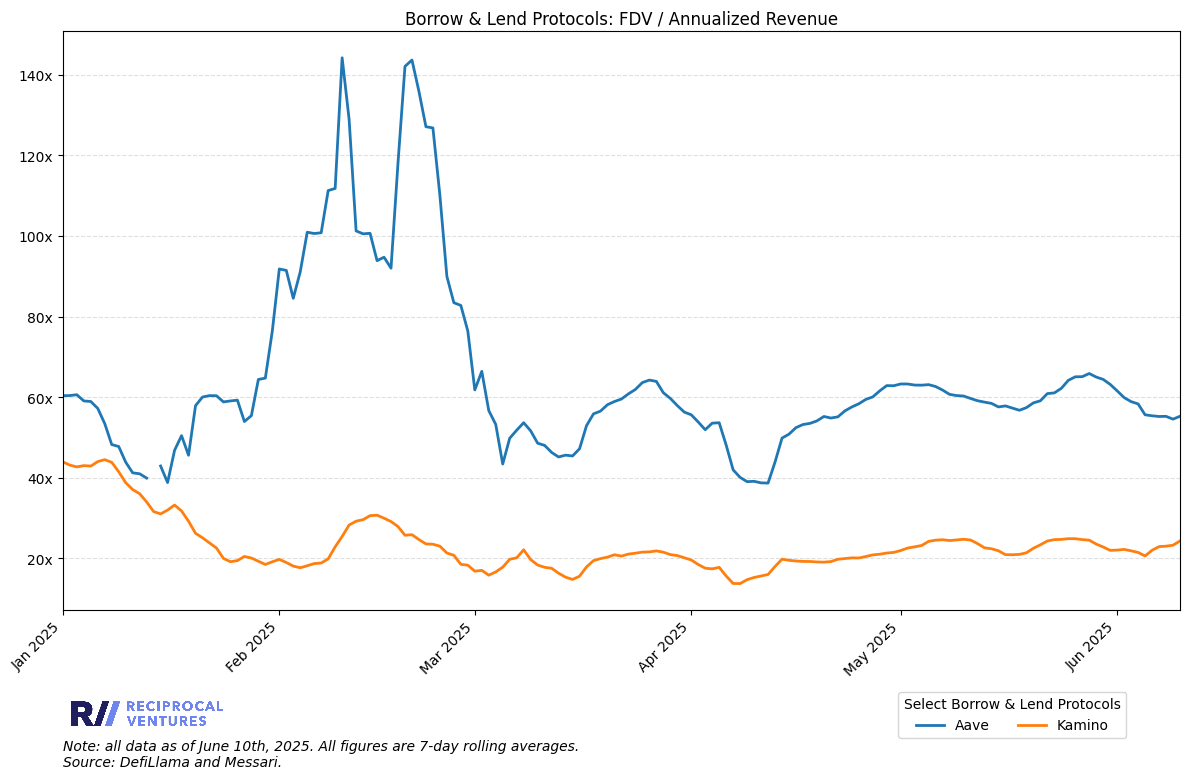


Borrow & Lend Protocols FDV / Annualized Revenue Statistics (Excluding Kamino):
Median FDV / Annualized Revenue: 58x
80th Percentile FDV / Annualized Revenue: 66x
20th Percentile FDV / Annualized Revenue: 46x
Latest Multiple: 64x

Kamino FDV / Annualized Revenue Statistics:
Median FDV / Annualized Revenue: 22x
80th Percentile FDV / Annualized Revenue: 27x
20th Percentile FDV / Annualized Revenue: 18x
Latest Multiple: 29x



In [84]:
# Call the function for perp dexs
borrow_lend_protocols = {'aave': 'Aave',
          'kamino': 'Kamino',
         }

# 'bottom_metric' should be 'Fees' or 'Revenue'; 'top_metric' should be 'FDV' or 'MCAP'
start_date = '2025-01-01'
assets = borrow_lend_protocols
breakout_asset = ('kamino', 'Kamino')
bottom_metric = 'Revenue'
top_metric = 'FDV'
category_title = 'Borrow & Lend Protocols'

borrow_lend_stats, breakout_stats = revenue_vs_fdv_asset(
    start_date     = start_date,
    assets         = assets,
    breakout_asset = breakout_asset,
    bottom_metric  = bottom_metric,
    top_metric     = top_metric,
    category_title = category_title
)

In [87]:
# Function for plotting fees comparison
def fees_and_revenue_comparison(start_date, asset_slugs, asset_names):
    master_df = None
    
    # Load fees and revenue data
    for asset_slug in asset_slugs:
        metrics = ['Fees', 'Revenue']
        interim_df = None
        for metric in metrics:
            asset_path = f"raw-data/defillama-raw-data/defillama_{asset_slug}_{metric}.json"
            with open(asset_path) as asset_f:
                asset_data = json.load(asset_f)

            # Clean up asset dataframe
            asset_df = pd.DataFrame(asset_data["totalDataChart"], columns=["timestamp", f"{asset_slug}-{metric}"])
            asset_df["date"] = pd.to_datetime(asset_df["timestamp"], unit="s")
            asset_df = asset_df[["date", f"{asset_slug}-{metric}"]]
        
            # Merge metric-level asset dataframes for a given asset into the interim dataframe
            interim_df = asset_df if interim_df is None else interim_df.merge(asset_df, on="date", how="inner")
            interim_df = interim_df.sort_values("date").reset_index(drop=True)

        # Merge interim dataframe into the master dataframe
        master_df = interim_df if master_df is None else master_df.merge(interim_df, on="date", how="outer")
        master_df = master_df.sort_values("date").reset_index(drop=True)

    # Calculate fees comparison and revenue comparison
    for metric in metrics:
        master_df[f'{asset_slugs[0]} as % of {asset_slugs[1]}: {metric}'] = (master_df[f'{asset_slugs[0]}-{metric}'] / master_df[f'{asset_slugs[1]}-{metric}']).rolling(window=7).mean()
    
    master_df = master_df[['date',f'{asset_slugs[0]} as % of {asset_slugs[1]}: {metrics[0]}',f'{asset_slugs[0]} as % of {asset_slugs[1]}: {metrics[1]}']]
    
    # Cut off df_master to only be after start date
    master_df = master_df[master_df['date'] >= start_date]
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(10, 6))

    # Create color palette
    color_list = ['#1f1f60',
                'grey',
               ]
            
    # Prepare the values and colors in the right order
    dates   = master_df['date']
    series_list = [master_df[f'{asset_slugs[0]} as % of {asset_slugs[1]}: {metric}'] for metric in metrics]
    labels_list  = [metric for metric in metrics]
    colors_list = [color for color in color_list]
    
    # Plotting the line chart with custom colors
    for i, metric in enumerate(metrics):
        ax.plot(
            dates, 
            series_list[i], 
            label = labels_list[i], 
            color = colors_list[i],
            linewidth=2
        )
    
    # Setting labels and title
    ax.set_title(f'{asset_names[0]} as % of {asset_names[1]}: {metrics[0]} and {metrics[1]}')
    ax.margins(x=0)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x*100:,.0f}%'))
    ax.set_ylim(bottom=0)

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.08, -0.25))
    
    # Add sources and note
    text_box = ax.text(0, -0.40, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Center the legend below the chart
    plt.legend(title=f'Select {category_title}', bbox_to_anchor=(0.85, -0.17), loc='upper center', ncol=2)
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/{asset_names[0]} as % of {asset_names[1]} {metrics[0]} and {metrics[1]}.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

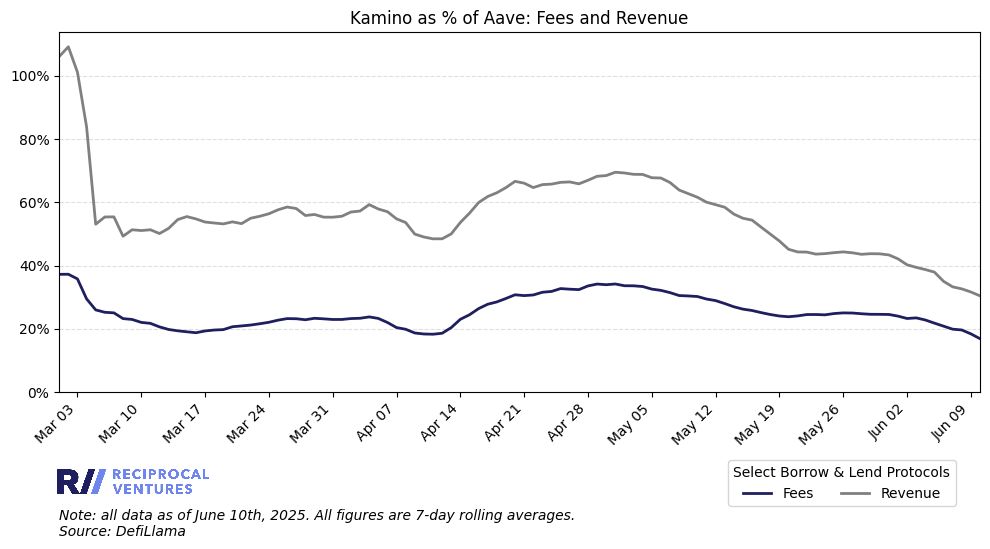

In [88]:
# call the function
start_date = '2025-03-01'
asset_slugs = ['kamino', 'aave']
asset_names = ['Kamino', 'Aave']

fees_and_revenue_comparison(start_date, asset_slugs, asset_names)